In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from pypots.data.generating import gene_physionet2012
from pypots.utils.random import set_random_seed

In [7]:
tsdb.list()

['physionet_2012',
 'physionet_2019',
 'electricity_load_diagrams',
 'beijing_multisite_air_quality',
 'italy_air_quality',
 'vessel_ais',
 'electricity_transformer_temperature',
 'pems_traffic',
 'solar_alabama',
 'ucr_uea_ACSF1',
 'ucr_uea_Adiac',
 'ucr_uea_AllGestureWiimoteX',
 'ucr_uea_AllGestureWiimoteY',
 'ucr_uea_AllGestureWiimoteZ',
 'ucr_uea_ArrowHead',
 'ucr_uea_Beef',
 'ucr_uea_BeetleFly',
 'ucr_uea_BirdChicken',
 'ucr_uea_BME',
 'ucr_uea_Car',
 'ucr_uea_CBF',
 'ucr_uea_Chinatown',
 'ucr_uea_ChlorineConcentration',
 'ucr_uea_CinCECGTorso',
 'ucr_uea_Coffee',
 'ucr_uea_Computers',
 'ucr_uea_CricketX',
 'ucr_uea_CricketY',
 'ucr_uea_CricketZ',
 'ucr_uea_Crop',
 'ucr_uea_DiatomSizeReduction',
 'ucr_uea_DistalPhalanxOutlineCorrect',
 'ucr_uea_DistalPhalanxOutlineAgeGroup',
 'ucr_uea_DistalPhalanxTW',
 'ucr_uea_DodgerLoopDay',
 'ucr_uea_DodgerLoopGame',
 'ucr_uea_DodgerLoopWeekend',
 'ucr_uea_Earthquakes',
 'ucr_uea_ECG200',
 'ucr_uea_ECG5000',
 'ucr_uea_ECGFiveDays',
 'ucr_uea_E

In [40]:
data_ = tsdb.load('italy_air_quality')

2025-02-28 14:15:20 [INFO]: You're using dataset italy_air_quality, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/italy_air_quality
2025-02-28 14:15:20 [INFO]: Start downloading...
2025-02-28 14:15:29 [INFO]: Successfully downloaded data to /var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/tmpi7hqh6f3/air+quality.zip
2025-02-28 14:15:29 [INFO]: Successfully extracted data to /Users/louis/.pypots/tsdb/italy_air_quality
2025-02-28 14:15:29 [INFO]: Successfully saved to /Users/louis/.pypots/tsdb/italy_air_quality/italy_air_quality_cache.pkl
2025-02-28 14:15:29 [INFO]: Loaded successfully!


In [63]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = data_['X']

# Combine 'Date' and 'Time' into a single datetime column.
# Adjust the format as needed (here the format is: day/month/year hour.minute.second)
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')

# Optional: extract additional time features if they are useful for your ML model
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Hour'] = df['Datetime'].dt.hour

# Drop the original 'Date' and 'Time' columns if they are no longer needed
#df.drop(['Date', 'Time'], axis=1, inplace=True)

# Replace error codes (e.g., -200) with NaN for cleaning
#df.replace(-200, np.nan, inplace=True)

# Identify the columns to normalize.
# If you want to normalize all numeric columns (excluding the datetime column), you can do:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Initialize the scaler (here we use StandardScaler for z-score normalization)
scaler = StandardScaler()

# Fit and transform the numeric columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.sort_values(by = ['Date','Hour'], inplace = True)


# Your dataframe 'df' is now ready for machine learning, with a datetime feature and normalized numeric values.
df.head()



,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime,Year,Month,Day,Hour
7110,01/01/2005,00.00.00,-2.135042,-0.009066,-0.29267,0.056414,-0.498358,-1.431966,0.164639,-2.033730,-1.056283,0.494465,-0.036534,0.012001,0.186663,2005-01-01 00:00:00,2005,1,1,0
7111,01/01/2005,01.00.00,0.461122,0.685263,-0.29267,0.167585,0.103427,0.180184,-0.453419,0.376977,-0.786582,1.404921,-0.103661,0.218978,0.187148,2005-01-01 01:00:00,2005,1,1,1
7112,01/01/2005,02.00.00,0.472712,0.375998,-0.29267,0.136167,-0.048480,0.510384,-0.177001,0.558174,-0.833673,0.831509,-0.089773,0.205310,0.187468,2005-01-01 02:00:00,2005,1,1,2
7113,01/01/2005,03.00.00,0.475288,0.345678,-0.29267,0.138584,-0.039716,-1.431966,-0.145943,-2.033730,-0.835813,0.702382,-0.112920,0.281462,0.187479,2005-01-01 03:00:00,2005,1,1,3
7114,01/01/2005,04.00.00,0.464985,0.015190,-0.29267,0.090249,-0.302631,0.327803,0.108734,0.534540,-0.908590,0.341263,-0.126809,0.308798,0.187368,2005-01-01 04:00:00,2005,1,1,4


In [70]:
import pandas as pd
import numpy as np

# Assume df is your preprocessed DataFrame from before,
# and that it contains a 'Datetime' column.
# Define the relevant columns (d features) you wish to use:
relevant_columns = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
                    'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)',
                    'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

# Extract the day and hour from the Datetime column
df['Day'] = df['Datetime'].dt.date
df['Hour'] = df['Datetime'].dt.hour

# Group by day and reindex each day to ensure it has exactly 24 hours.
daily_arrays = []
for day, group in df.groupby('Day'):
    # Set the hour as index and sort by hour
    group = group.set_index('Hour').sort_index()
    # Reindex to ensure every hour from 0 to 23 is present; missing hours will be filled with NaN.
    group = group.reindex(range(24))
    # Extract the relevant columns and convert to a numpy array of shape (24, d)
    daily_array = group[relevant_columns].values
    daily_arrays.append(daily_array)

# Convert list of daily arrays into a single numpy array with shape (N, 24, d)
data_array = np.stack(daily_arrays, axis=0)
print("Shape of the reshaped data:", data_array.shape)


Shape of the reshaped data: (391, 24, 13)


In [97]:
import numpy as np
from pygrinder import mcar
import torch

X = torch.tensor(data_array).float()

## Normalize_data
mean, std = np.nanmean(X,axis=0)[None,:], np.nanstd(X, axis=0)[None,:]
std[std==0] = 1
X_normalized = (X - mean) / std
X_normalized = X_normalized.clip(min=-2,max=2)

X = mcar(torch.clone(X_normalized), p = 0.5)

In [98]:
dataset = {'X' : X}
len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

In [99]:
X.shape

torch.Size([391, 24, 13])

In [112]:
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

from pypots.imputation import GP_VAE

gpvae = GP_VAE(n_steps = dataset_train['X'].shape[1], 
            n_features = dataset_train['X'].shape[2], 
            latent_size = 16, 
            epochs = 500, 
            batch_size = 32,
            beta = 1., 
            K = 10,  
            encoder_sizes = (128,), 
            decoder_sizes = (128,),
            optimizer = Adam(weight_decay=0.001), #lr = 1e-4
            patience = 30
            )

gpvae.model.backbone.alpha = 1e0
gpvae.model.backbone.beta = 1e-2
gpvae.model.backbone.gamma = 5 * 1e-5
gpvae.model.backbone.noise_sigma = 1e-3
gpvae.model.backbone.sampling = True
gpvae.model.backbone.use_mean = True
gpvae.model.backbone.noise_std = 1e-2
gpvae.model.backbone.detach = True
gpvae.model.backbone.compensate = False
gpvae.use_gp = False
gpvae.train_gp = False
gpvae.gp.plot_while_training = True

gpvae.model.backbone.p = 0.3
gpvae.model.backbone.device = 'cpu'

2025-02-28 14:41:39 [INFO]: No given device, using default device: cpu
2025-02-28 14:41:39 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-02-28 14:41:39 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 11,437


Model dimensions is:
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): ReLU()
  )
  (mu_layer): Linear(in_features=128, out_features=16, bias=True)
  (logvar_layer): Linear(in_features=128, out_features=16, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=13, bias=True)
  )
)


In [ ]:
gpvae.model.backbone.alpha = 1e-1

gpvae.fit(dataset_train, dataset_val)

2025-02-28 15:58:26 [INFO]: Epoch 001 - training loss: -0.5429, validation loss: -0.0640
2025-02-28 15:58:26 [INFO]: Epoch 002 - training loss: -0.5504, validation loss: 0.0050
2025-02-28 15:58:27 [INFO]: Epoch 003 - training loss: -0.5179, validation loss: 0.0929
2025-02-28 15:58:28 [INFO]: Epoch 004 - training loss: -0.5401, validation loss: 0.1521
2025-02-28 15:58:28 [INFO]: Epoch 005 - training loss: -0.5330, validation loss: 0.1671
2025-02-28 15:58:28 [INFO]: Epoch 006 - training loss: -0.5622, validation loss: -0.0224
2025-02-28 15:58:29 [INFO]: Epoch 007 - training loss: -0.5668, validation loss: 0.0199
2025-02-28 15:58:30 [INFO]: Epoch 008 - training loss: -0.4734, validation loss: 0.1191
2025-02-28 15:58:30 [INFO]: Epoch 009 - training loss: -0.5199, validation loss: 0.3840
2025-02-28 15:58:30 [INFO]: Epoch 010 - training loss: -0.4477, validation loss: 0.2100
2025-02-28 15:58:31 [INFO]: Epoch 011 - training loss: -0.5035, validation loss: 0.2567
2025-02-28 15:58:32 [INFO]: Ep

fitting kernel


Epoch 1/50: 9it [00:02,  4.22it/s]


Epoch 1/50: Training Loss = 0.063528, Validation Loss = 0.054776


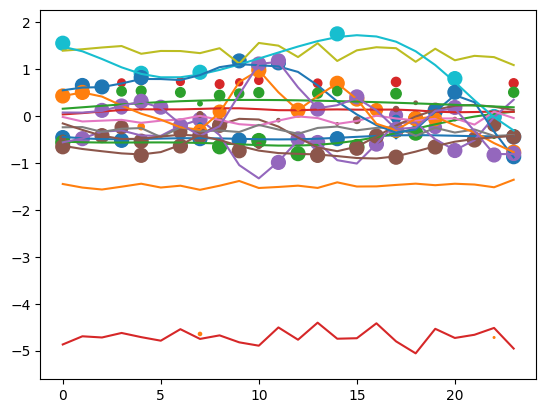

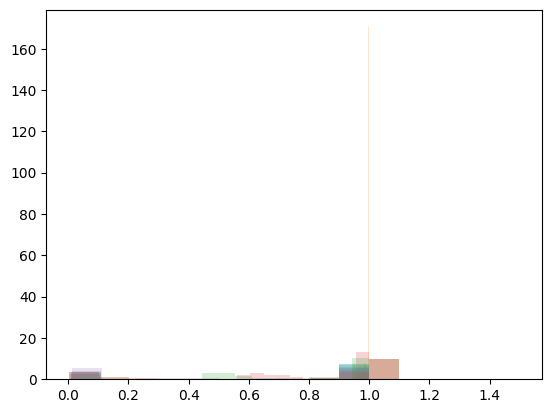

Epoch 2/50: 9it [00:02,  4.21it/s]


Epoch 2/50: Training Loss = 0.062974, Validation Loss = 0.052668


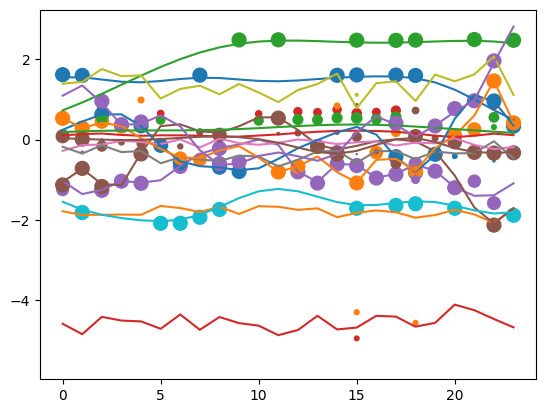

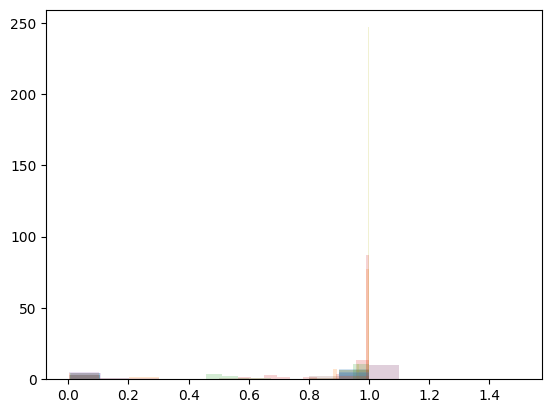

Epoch 3/50: 9it [00:02,  3.68it/s]


Epoch 3/50: Training Loss = 0.063284, Validation Loss = 0.053930


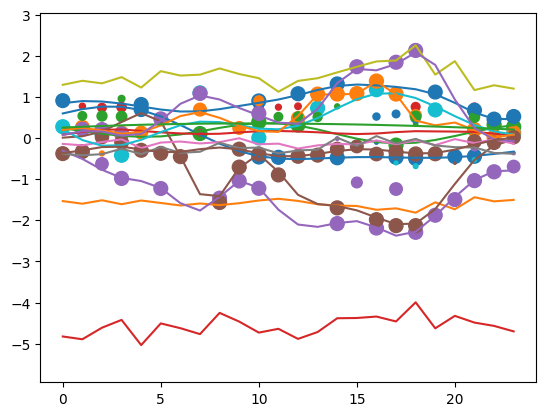

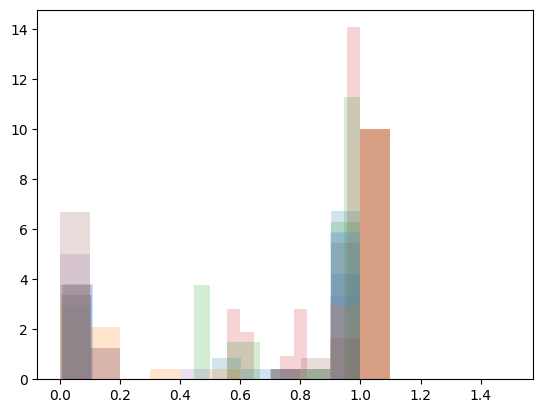

Epoch 4/50: 9it [00:02,  4.20it/s]


Epoch 4/50: Training Loss = 0.062631, Validation Loss = 0.053434


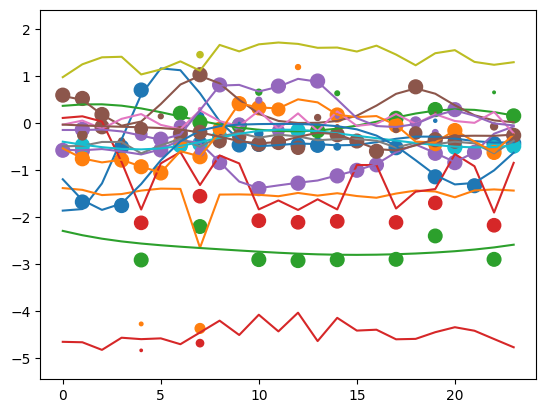

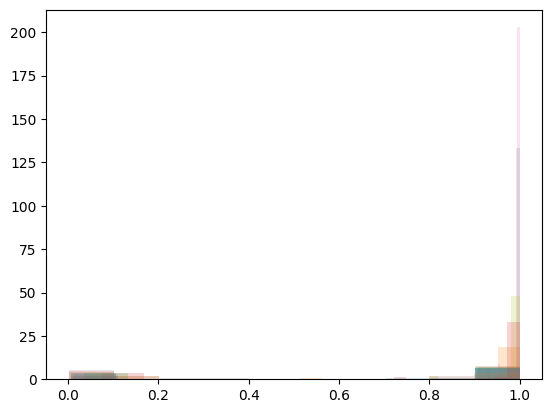

Epoch 5/50: 9it [00:02,  4.21it/s]


Epoch 5/50: Training Loss = 0.064799, Validation Loss = 0.056333


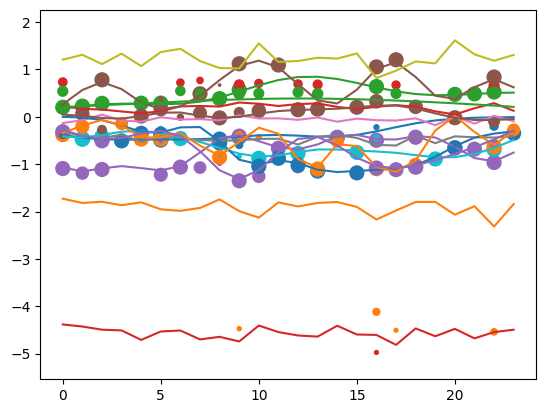

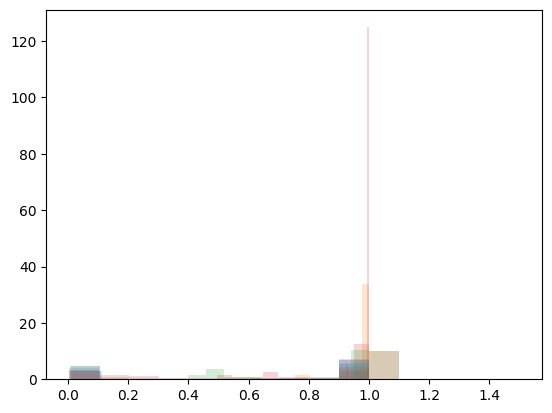

Epoch 6/50: 9it [00:02,  4.19it/s]


Epoch 6/50: Training Loss = 0.061089, Validation Loss = 0.052212


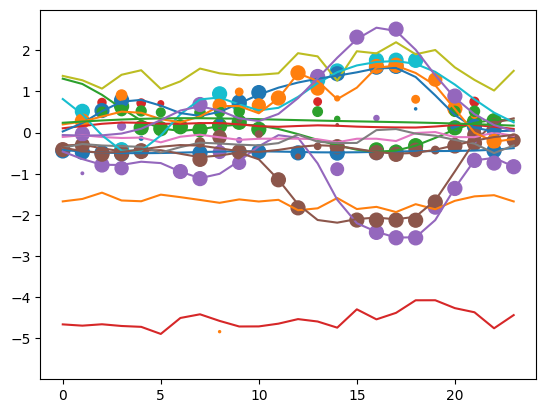

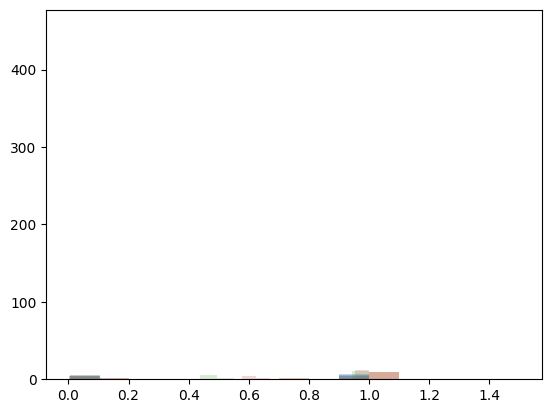

Epoch 7/50: 9it [00:02,  4.19it/s]


Epoch 7/50: Training Loss = 0.061267, Validation Loss = 0.052873


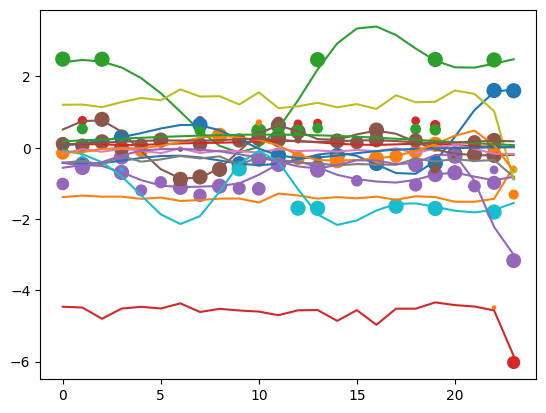

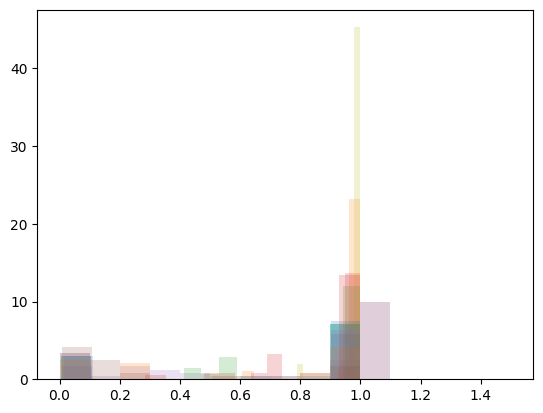

Epoch 8/50: 9it [00:02,  4.13it/s]


Epoch 8/50: Training Loss = 0.061577, Validation Loss = 0.056103


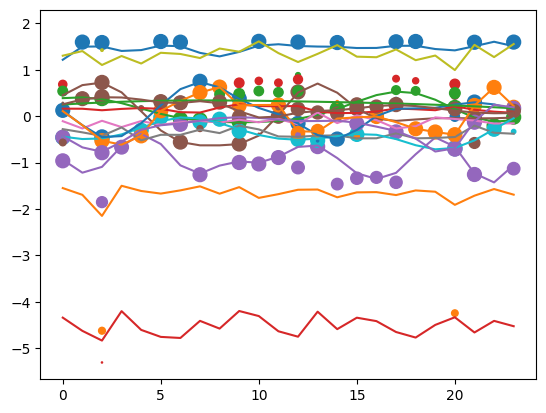

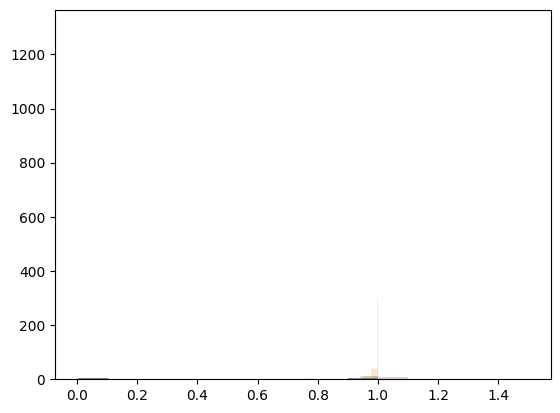

Epoch 9/50: 9it [00:02,  4.21it/s]


Epoch 9/50: Training Loss = 0.064551, Validation Loss = 0.055117


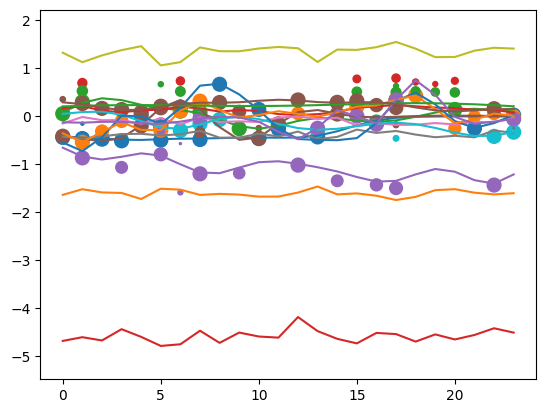

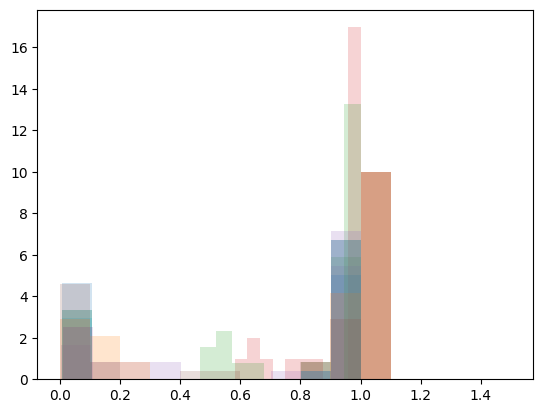

Epoch 10/50: 9it [00:02,  4.17it/s]


Epoch 10/50: Training Loss = 0.063106, Validation Loss = 0.052008


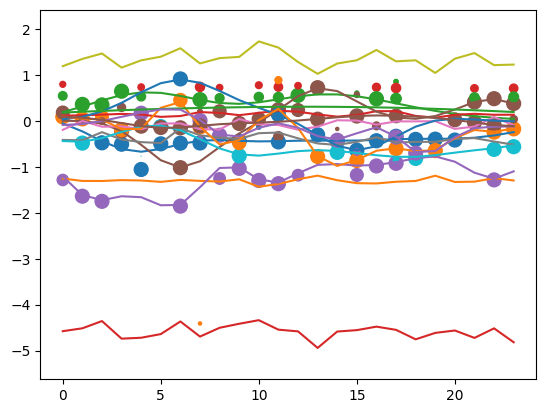

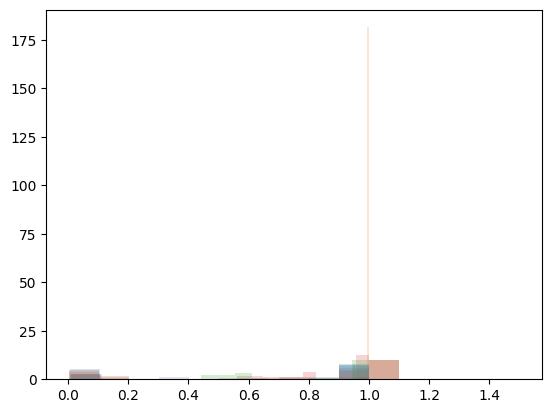

Epoch 11/50: 9it [00:02,  4.18it/s]


Epoch 11/50: Training Loss = 0.059336, Validation Loss = 0.052435


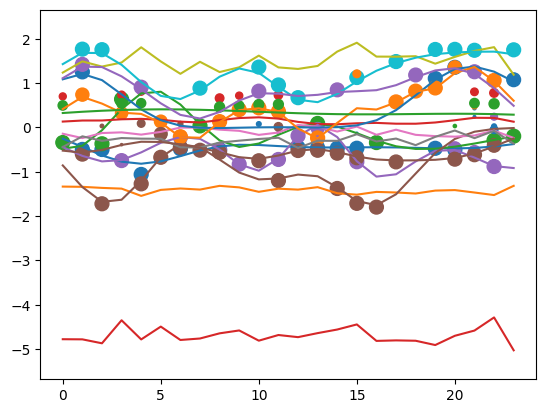

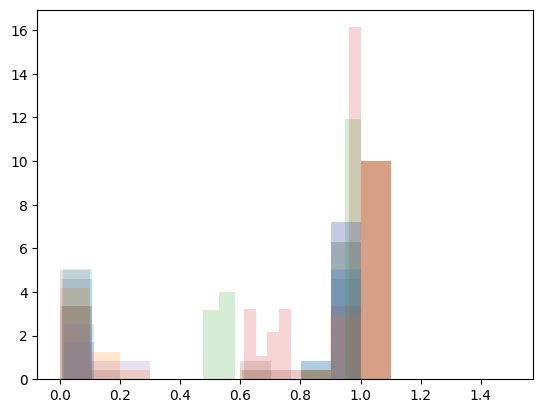

Epoch 12/50: 9it [00:02,  4.18it/s]


Epoch 12/50: Training Loss = 0.065819, Validation Loss = 0.053227


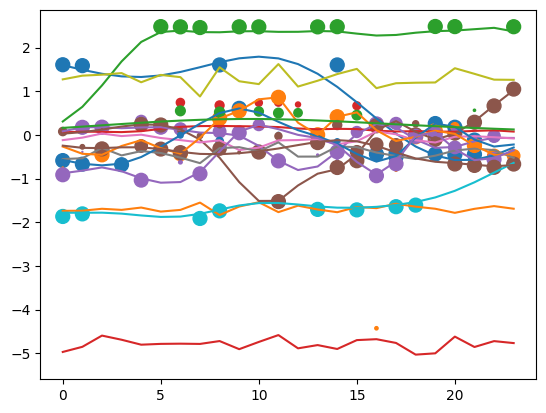

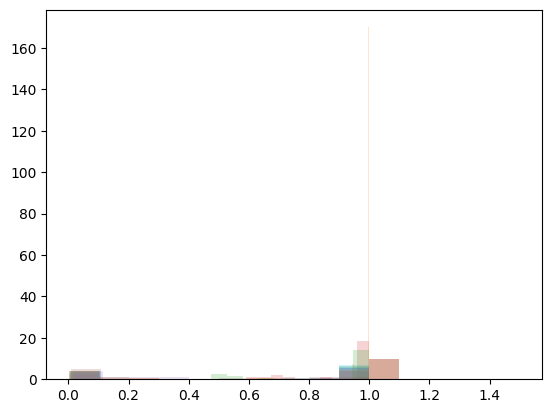

Epoch 13/50: 9it [00:02,  4.06it/s]


Epoch 13/50: Training Loss = 0.062154, Validation Loss = 0.059460


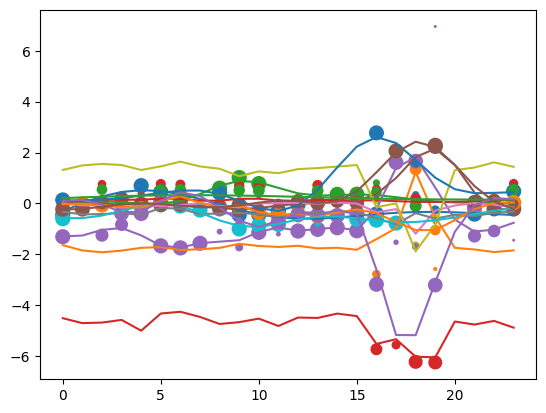

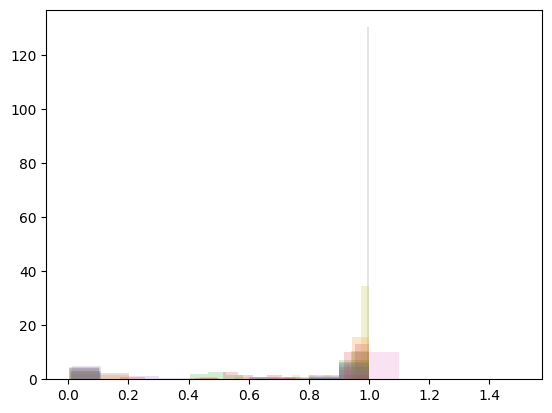

Epoch 14/50: 9it [00:02,  4.18it/s]


Epoch 14/50: Training Loss = 0.060170, Validation Loss = 0.051527


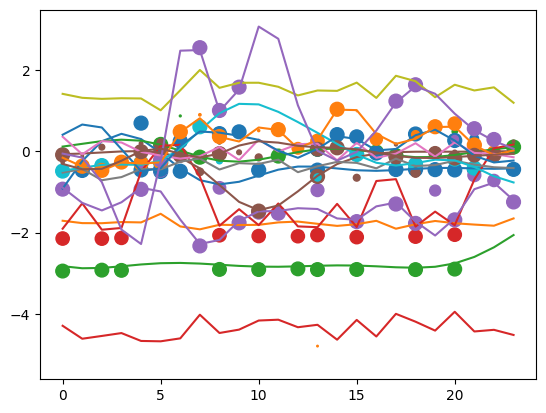

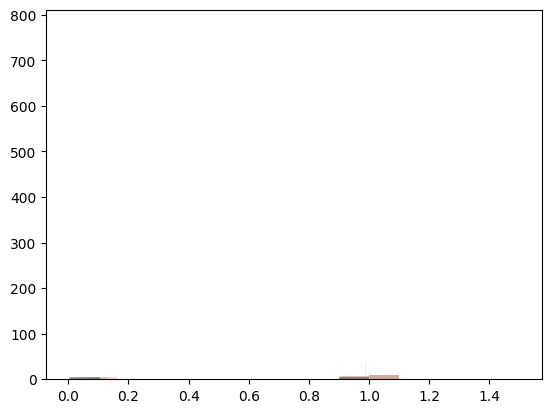

Epoch 15/50: 9it [00:02,  3.85it/s]


Epoch 15/50: Training Loss = 0.063406, Validation Loss = 0.058100


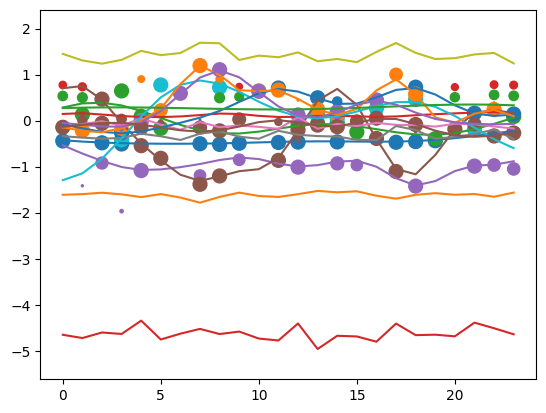

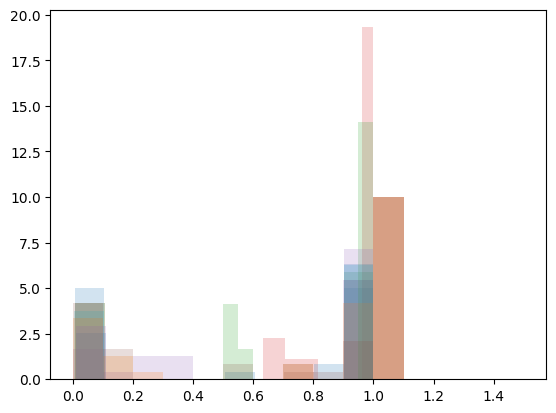

Epoch 16/50: 9it [00:02,  3.76it/s]


Epoch 16/50: Training Loss = 0.065415, Validation Loss = 0.054233


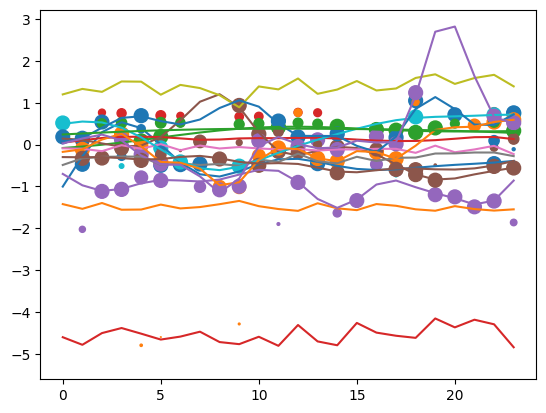

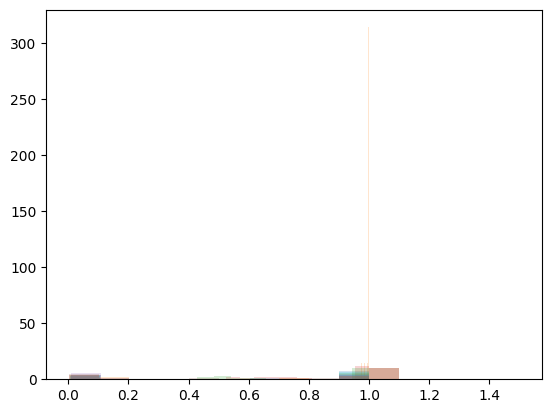

Epoch 17/50: 9it [00:02,  4.13it/s]


Epoch 17/50: Training Loss = 0.062298, Validation Loss = 0.059643


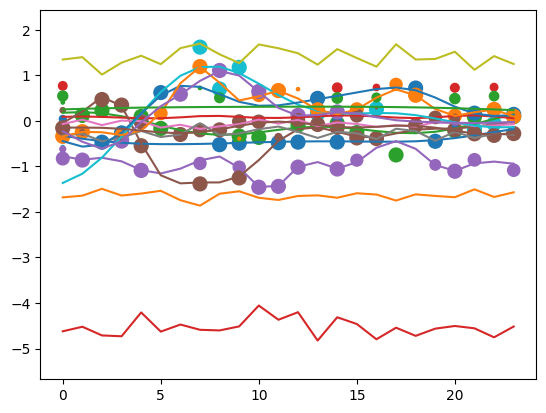

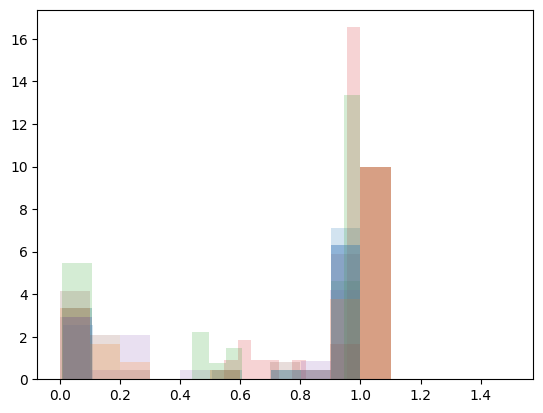

Epoch 18/50: 9it [00:02,  4.08it/s]


Epoch 18/50: Training Loss = 0.063974, Validation Loss = 0.055256


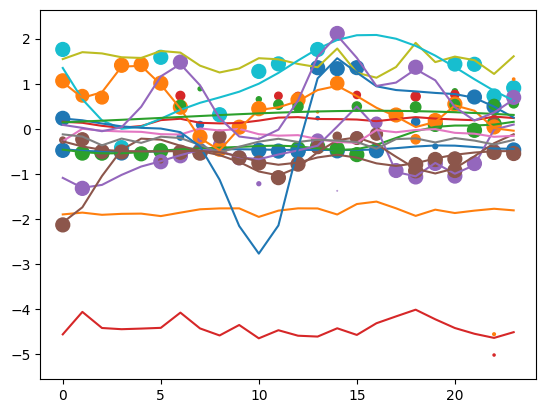

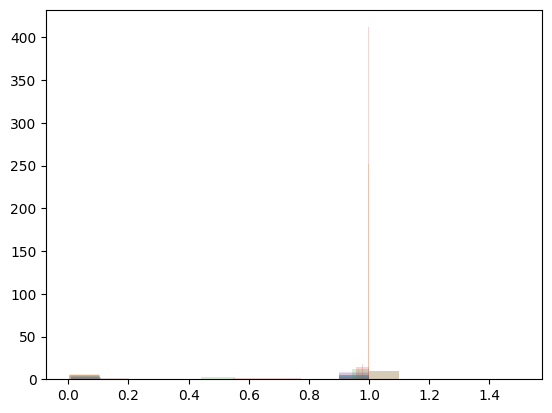

Epoch 19/50: 9it [00:02,  3.73it/s]


Epoch 19/50: Training Loss = 0.062867, Validation Loss = 0.055317


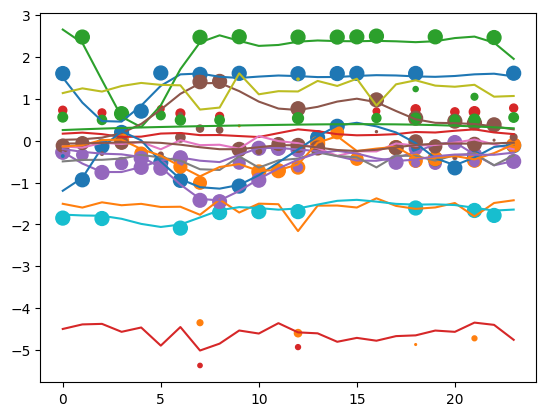

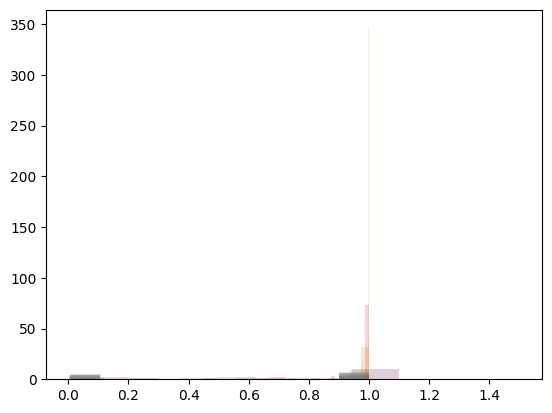

Epoch 20/50: 9it [00:02,  4.11it/s]


Epoch 20/50: Training Loss = 0.064632, Validation Loss = 0.051832


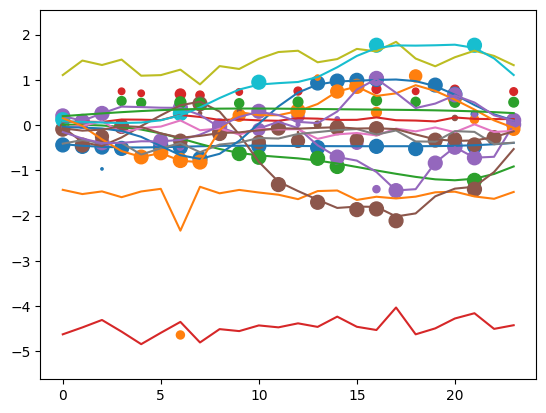

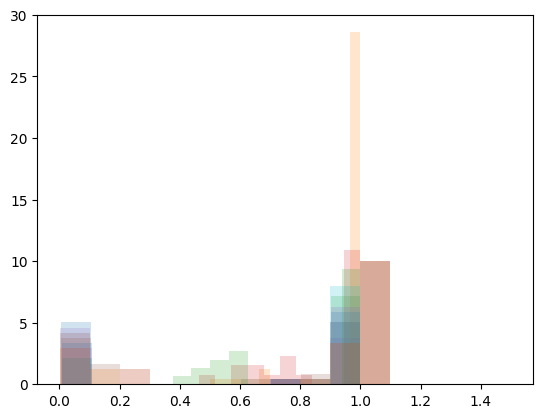

Epoch 21/50: 9it [00:02,  4.01it/s]


Epoch 21/50: Training Loss = 0.064615, Validation Loss = 0.050147


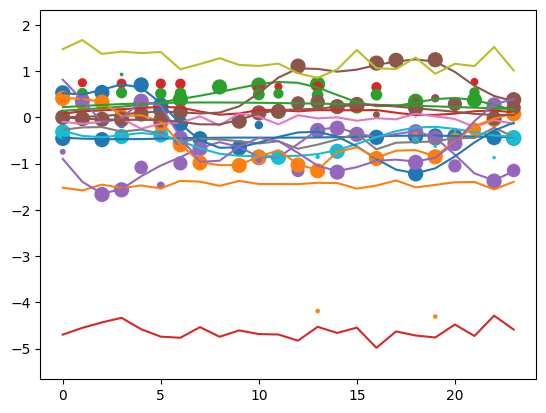

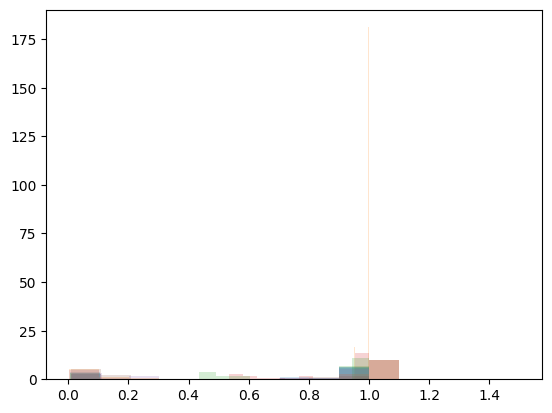

Epoch 22/50: 9it [00:02,  3.95it/s]


Epoch 22/50: Training Loss = 0.062259, Validation Loss = 0.051598


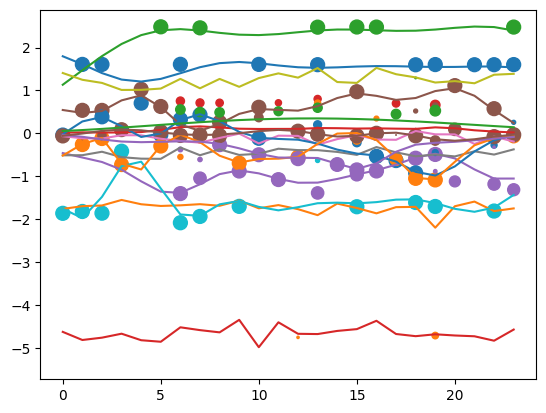

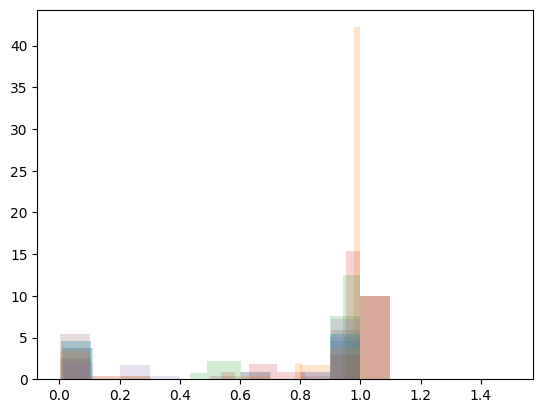

Epoch 23/50: 9it [00:02,  4.14it/s]


Epoch 23/50: Training Loss = 0.062801, Validation Loss = 0.053975


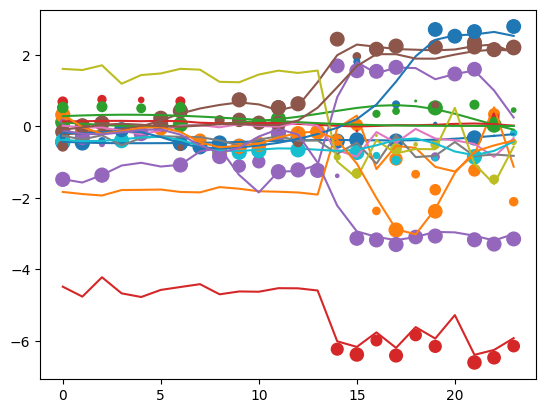

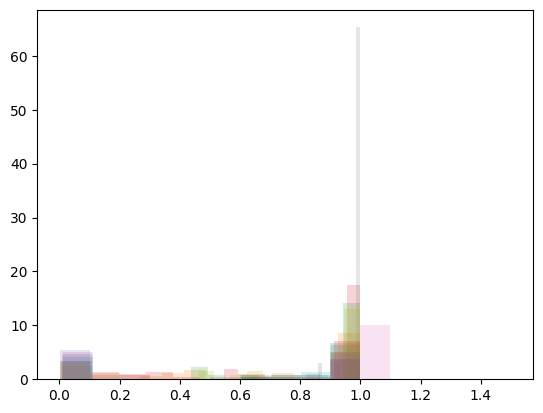

Epoch 24/50: 9it [00:02,  4.03it/s]


Epoch 24/50: Training Loss = 0.062839, Validation Loss = 0.050234


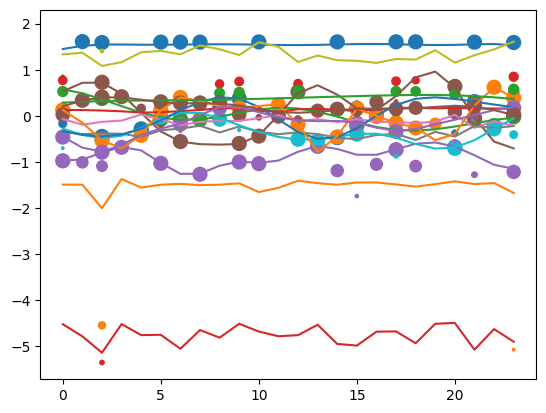

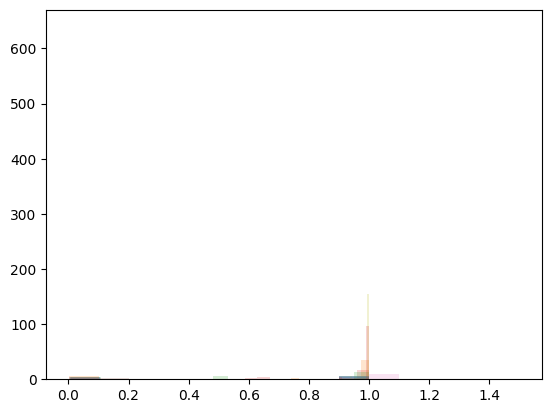

Epoch 25/50: 9it [00:02,  4.08it/s]


Epoch 25/50: Training Loss = 0.060345, Validation Loss = 0.057898


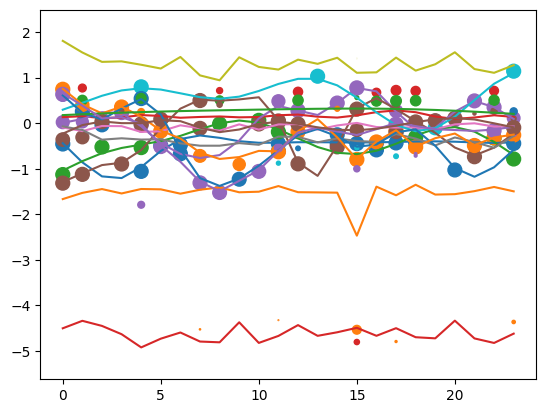

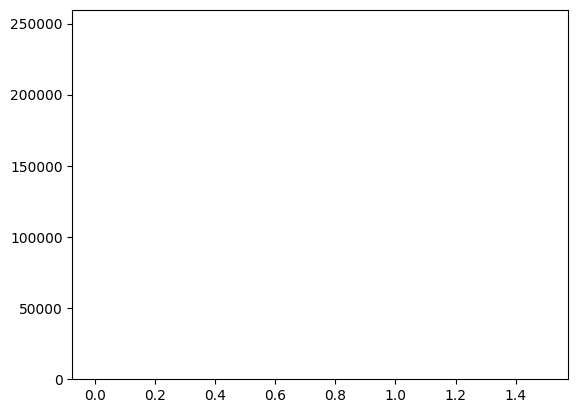

Epoch 26/50: 9it [00:02,  3.83it/s]


Epoch 26/50: Training Loss = 0.061031, Validation Loss = 0.052595


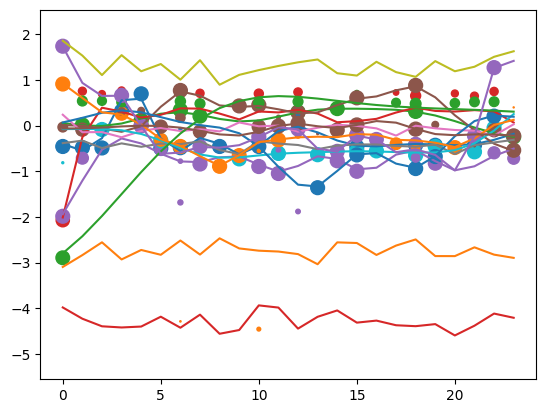

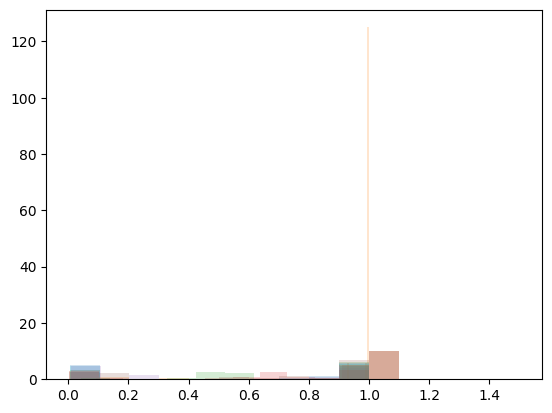

Epoch 27/50: 9it [00:02,  4.02it/s]


Epoch 27/50: Training Loss = 0.063321, Validation Loss = 0.054845


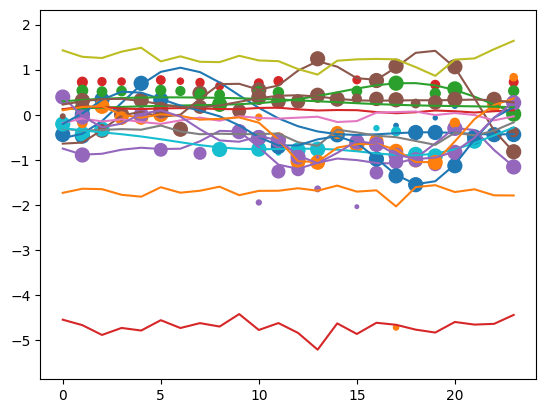

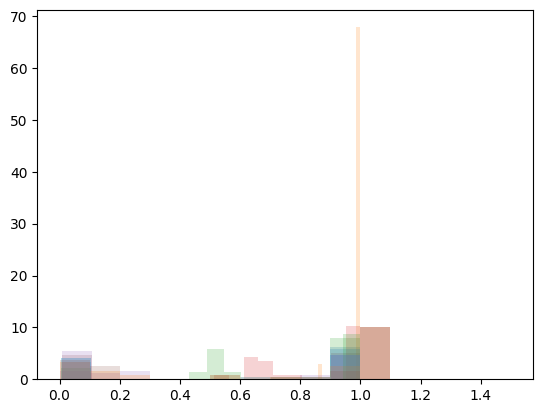

Epoch 28/50: 9it [00:02,  4.08it/s]


Epoch 28/50: Training Loss = 0.063732, Validation Loss = 0.053654


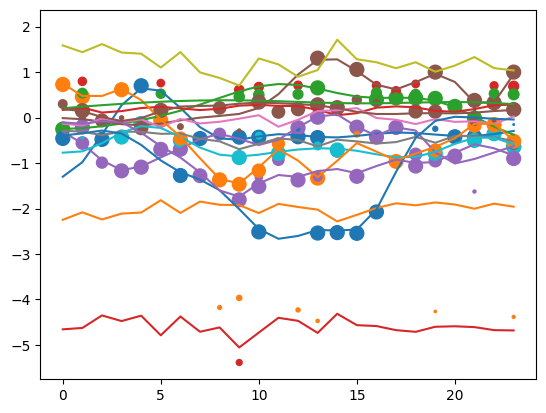

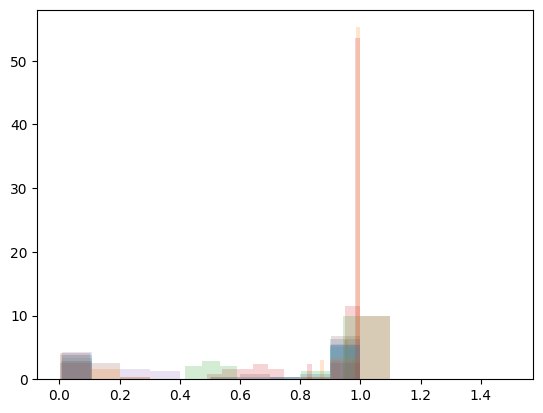

Epoch 29/50: 9it [00:02,  4.00it/s]


Epoch 29/50: Training Loss = 0.062387, Validation Loss = 0.052575


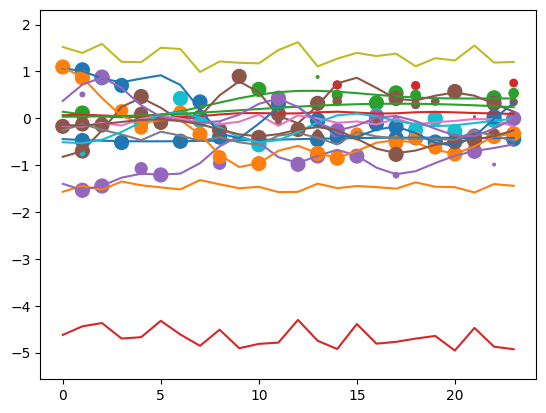

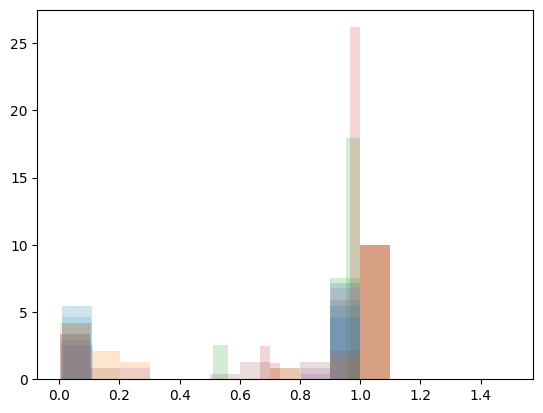

Epoch 30/50: 9it [00:02,  3.27it/s]


Epoch 30/50: Training Loss = 0.063548, Validation Loss = 0.051851


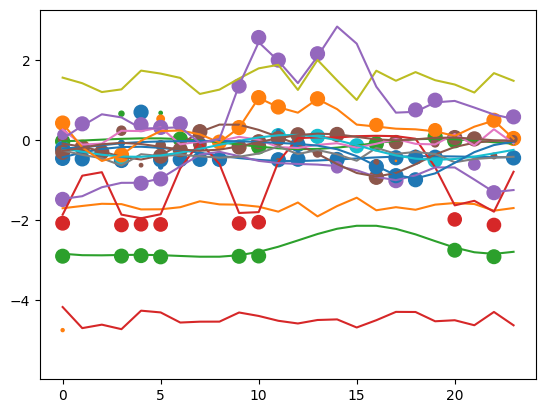

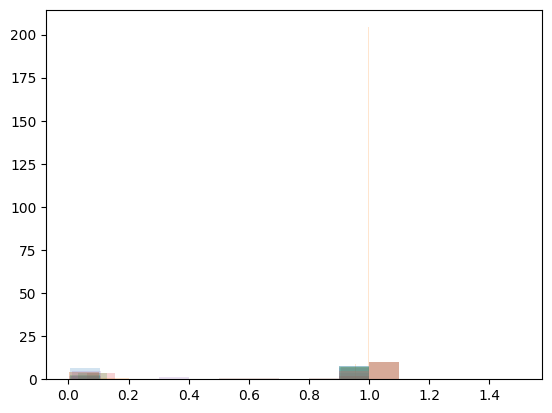

Epoch 31/50: 9it [00:02,  4.19it/s]


Epoch 31/50: Training Loss = 0.061029, Validation Loss = 0.050164


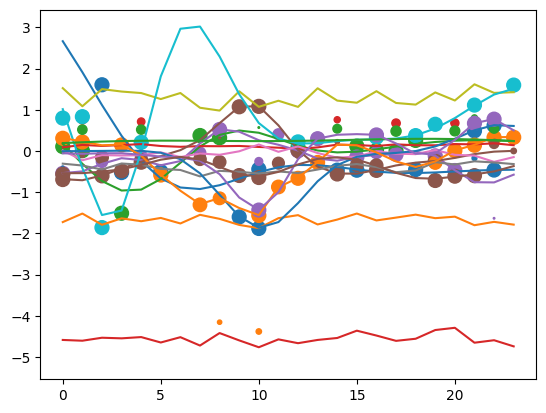

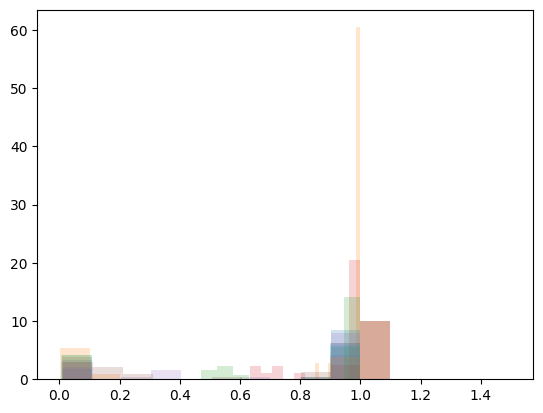

Epoch 32/50: 9it [00:02,  4.07it/s]


Epoch 32/50: Training Loss = 0.059131, Validation Loss = 0.050791


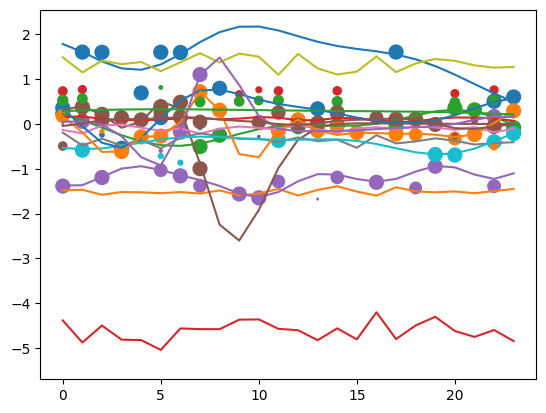

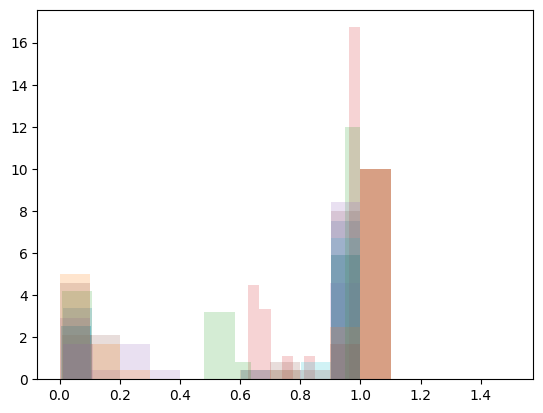

Epoch 33/50: 9it [00:02,  4.08it/s]


Epoch 33/50: Training Loss = 0.060620, Validation Loss = 0.053481


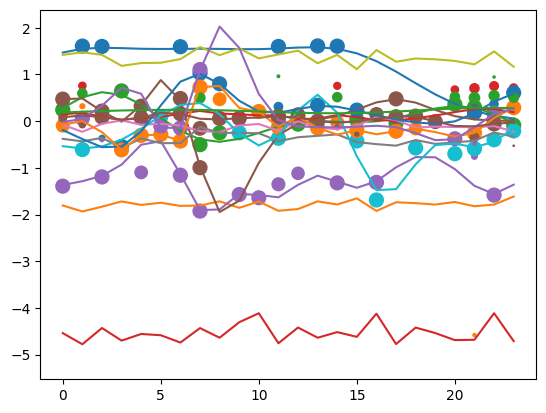

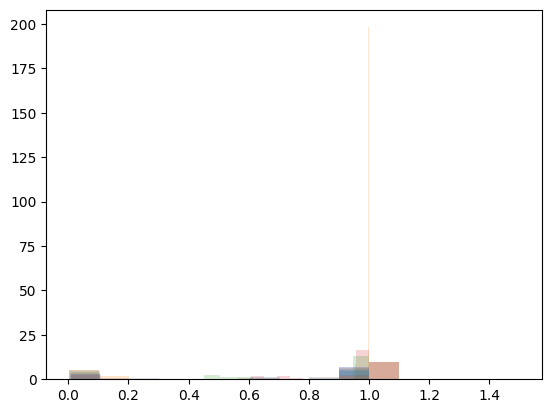

Epoch 34/50: 9it [00:02,  3.53it/s]


Epoch 34/50: Training Loss = 0.059406, Validation Loss = 0.055674


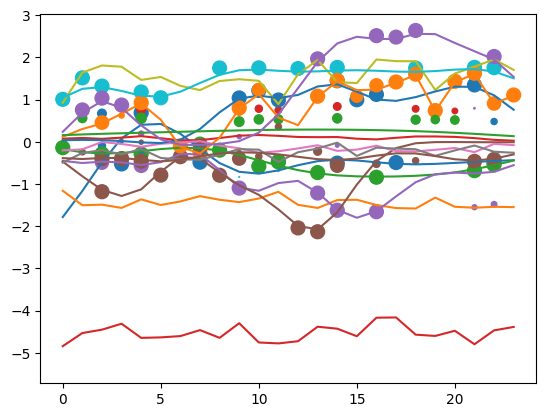

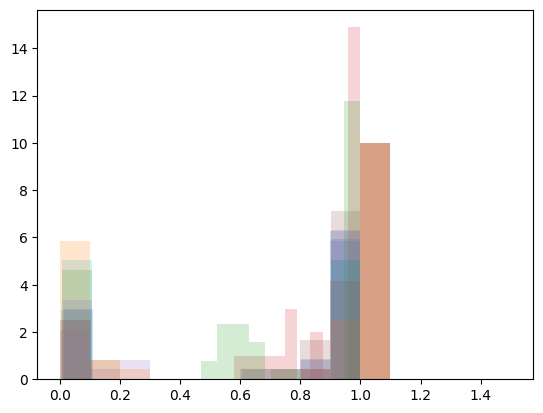

Epoch 35/50: 9it [00:02,  4.12it/s]


Epoch 35/50: Training Loss = 0.062720, Validation Loss = 0.051998


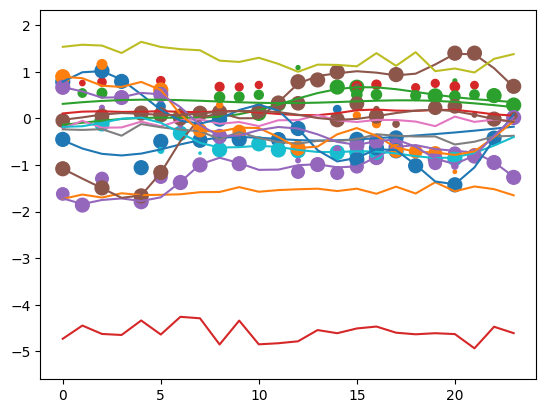

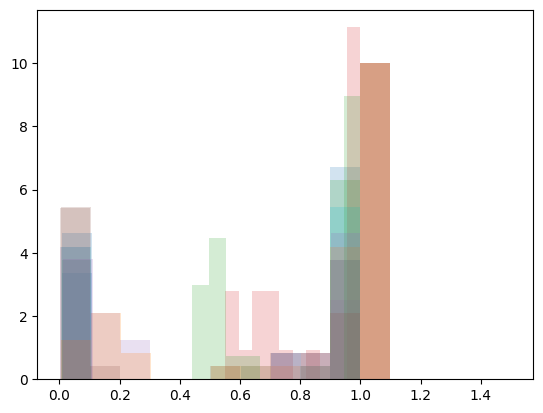

Epoch 36/50: 5it [00:01,  3.82it/s]


KeyboardInterrupt: 

In [129]:
gpvae.fit(dataset_train, dataset_val)

fitting kernel


Epoch 1/50: 9it [00:02,  3.78it/s]


Epoch 1/50: Training Loss = 0.047852, Validation Loss = 0.048411


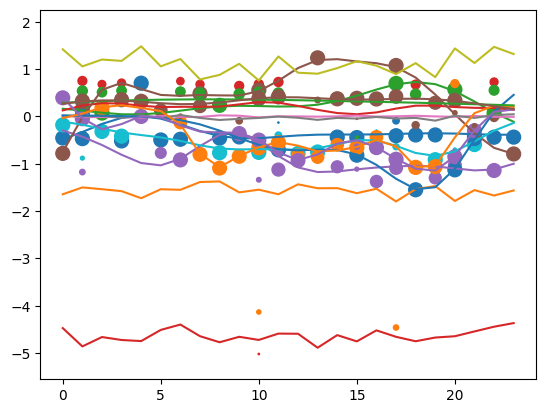

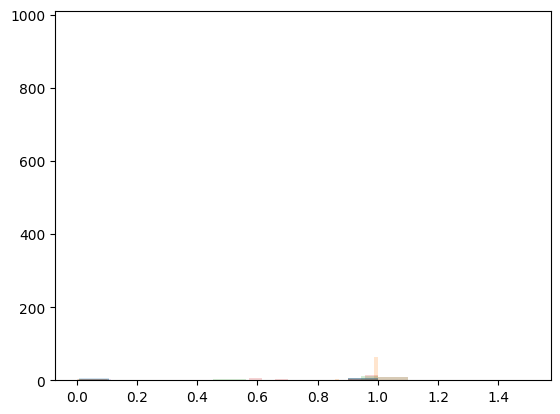

Epoch 2/50: 9it [00:02,  3.83it/s]


Epoch 2/50: Training Loss = 0.049851, Validation Loss = 0.048662


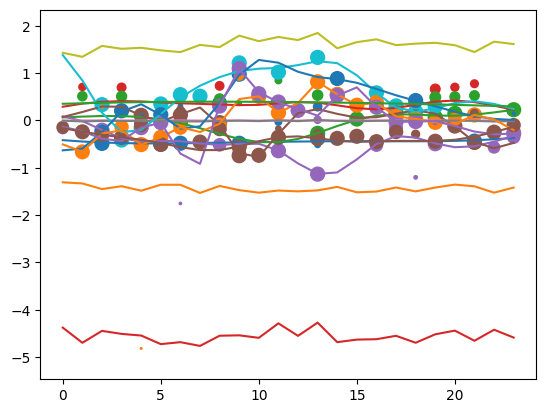

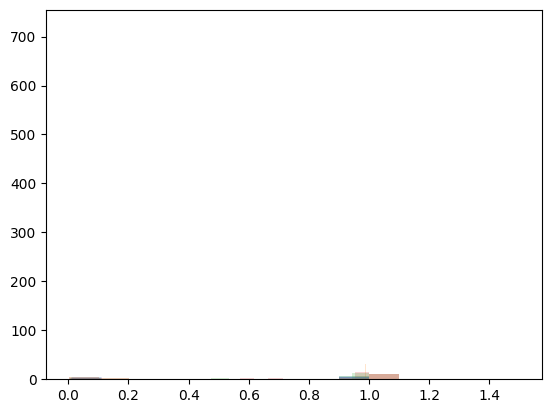

Epoch 3/50: 9it [00:02,  3.28it/s]


Epoch 3/50: Training Loss = 0.047487, Validation Loss = 0.048554


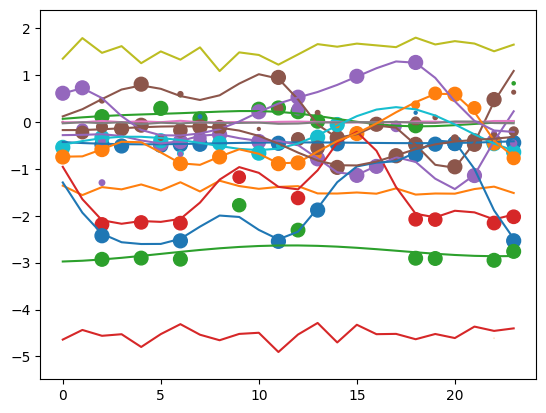

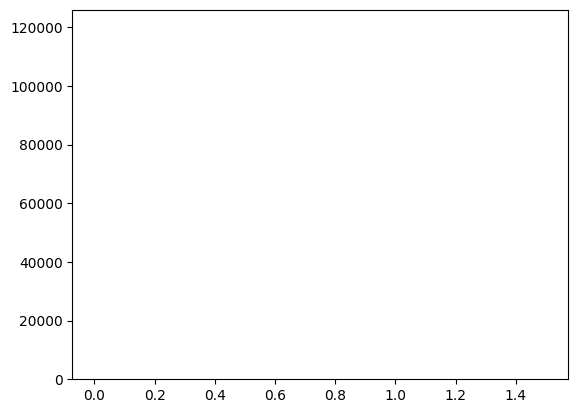

Epoch 4/50: 9it [00:02,  3.87it/s]


Epoch 4/50: Training Loss = 0.046479, Validation Loss = 0.048681


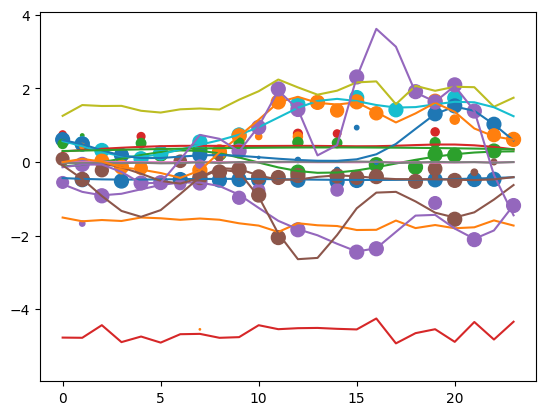

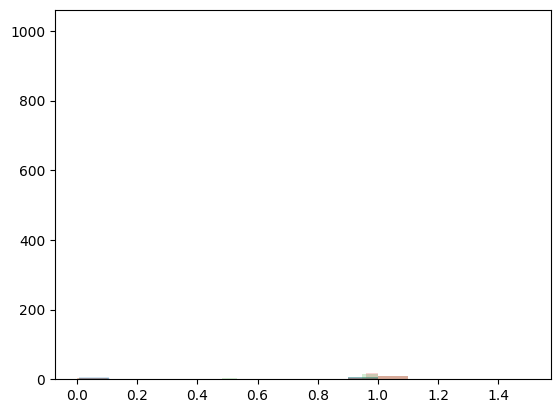

Epoch 5/50: 9it [00:02,  3.90it/s]


Epoch 5/50: Training Loss = 0.047553, Validation Loss = 0.049243


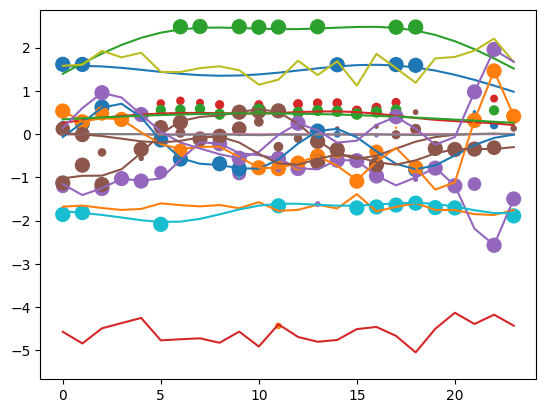

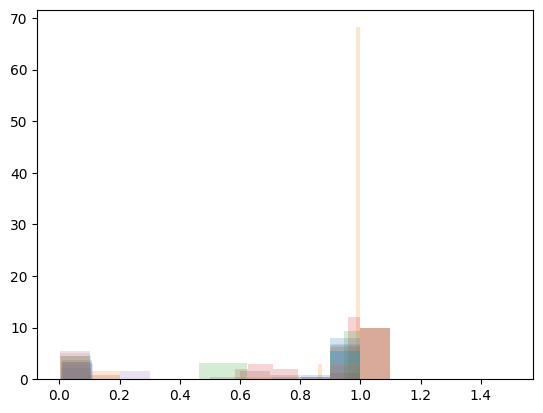

Epoch 6/50: 9it [00:02,  3.82it/s]


Epoch 6/50: Training Loss = 0.046279, Validation Loss = 0.052845


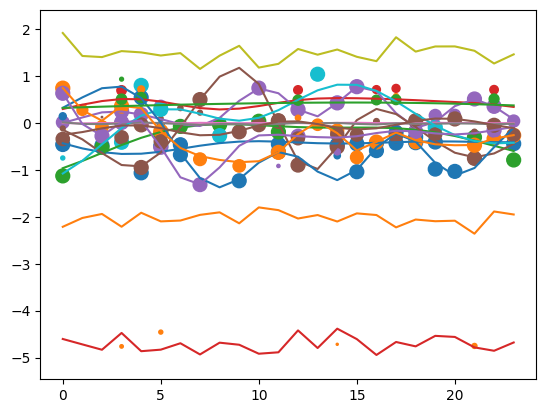

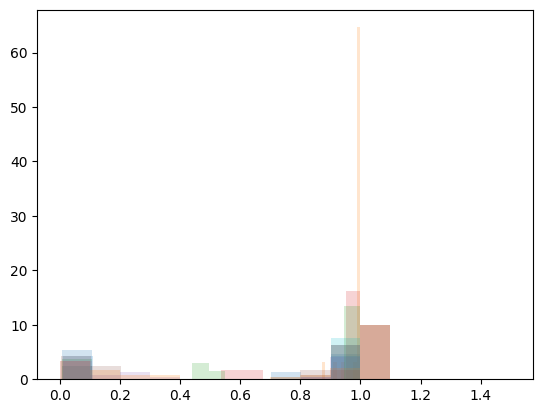

Epoch 7/50: 9it [00:02,  3.84it/s]


Epoch 7/50: Training Loss = 0.045951, Validation Loss = 0.051163


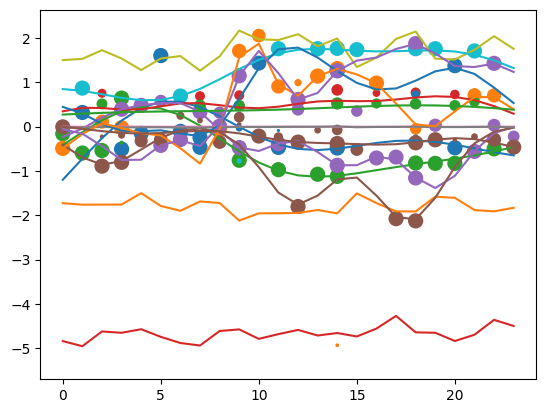

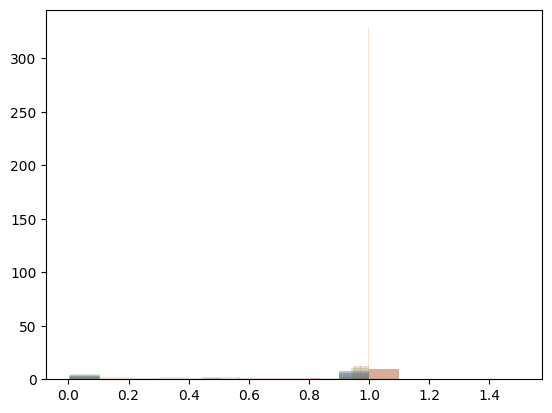

Epoch 8/50: 9it [00:02,  3.84it/s]


Epoch 8/50: Training Loss = 0.049956, Validation Loss = 0.052620


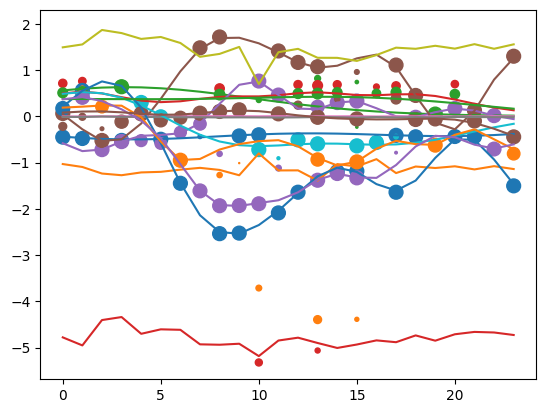

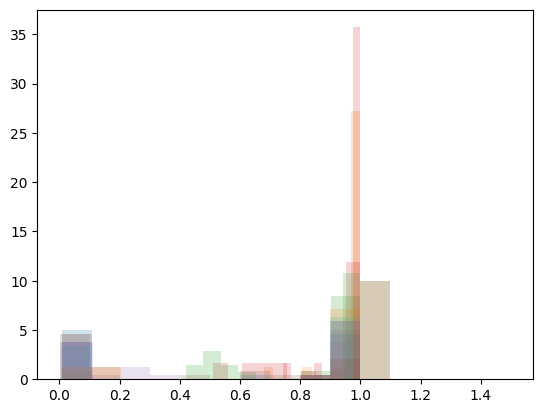

Epoch 9/50: 9it [00:02,  3.66it/s]


Epoch 9/50: Training Loss = 0.046184, Validation Loss = 0.049630


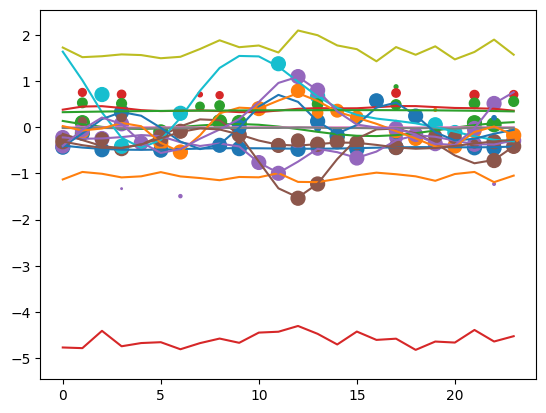

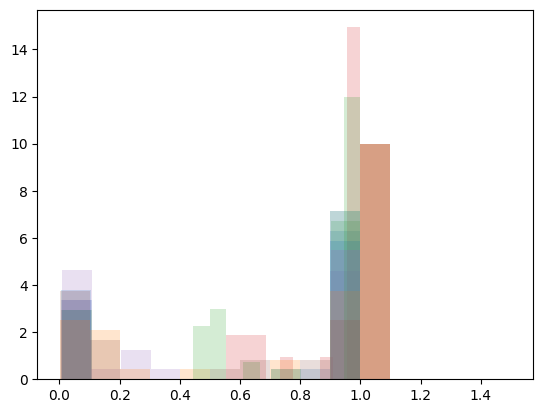

Epoch 10/50: 9it [00:02,  3.46it/s]


Epoch 10/50: Training Loss = 0.047342, Validation Loss = 0.048348


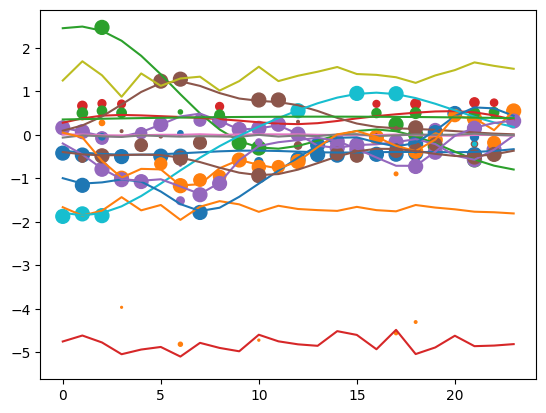

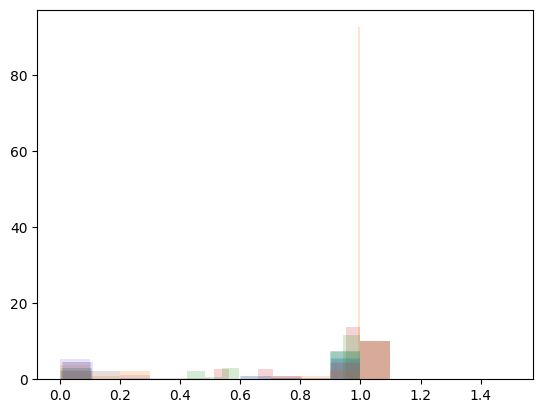

Epoch 11/50: 9it [00:02,  3.80it/s]


Epoch 11/50: Training Loss = 0.045366, Validation Loss = 0.052058


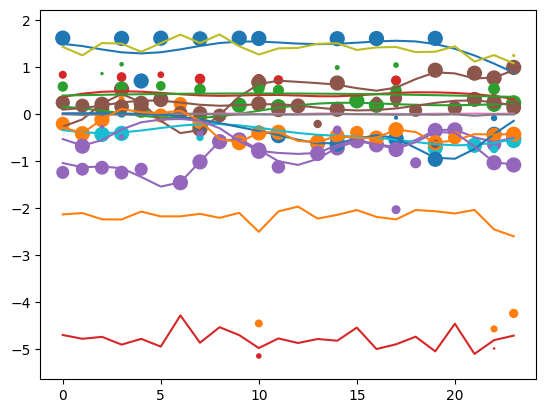

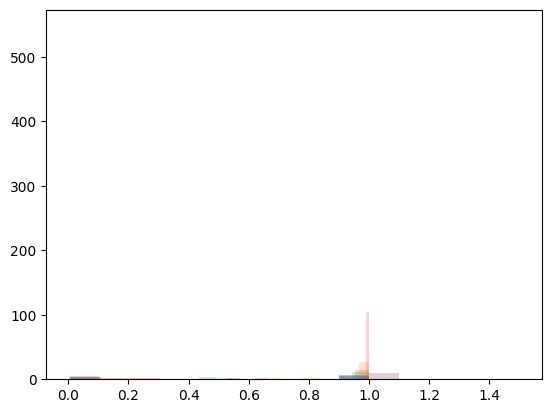

Epoch 12/50: 9it [00:02,  3.82it/s]


Epoch 12/50: Training Loss = 0.049230, Validation Loss = 0.050957



KeyboardInterrupt



In [131]:
gpvae.gp.plot_while_training = True
gpvae.fit_kernel(dataset_train, dataset_val, training_iter = 50)

In [ ]:
torch.save(gpvae.model.backbone.encoder.state_dict().copy(), 'encoder')
torch.save(gpvae.model.backbone.decoder.state_dict().copy(), 'decoder')

In [ ]:
state_dict = torch.load('encoder');
gpvae.model.backbone.encoder.load_state_dict(state_dict);
state_dict = torch.load('decoder');
gpvae.model.backbone.decoder.load_state_dict(state_dict);

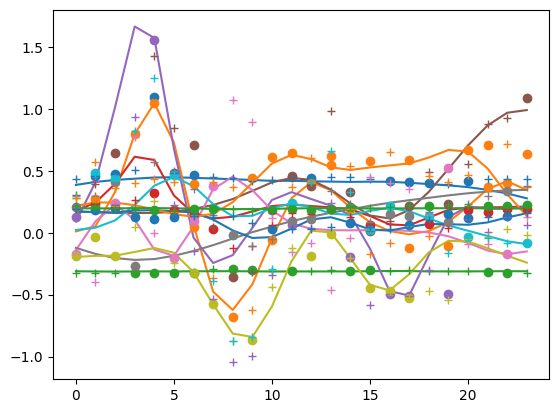

In [132]:
X_val_imputed = gpvae.impute(dataset_val, with_gp = True)
plt.plot(X_val_imputed[0]);
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val['X'][0],'o');
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val['X_ori'][0],'+');

In [127]:
from ipynbs.GP_regression_helpers import *

mse_obs, mse_hidden = plot_reconstruction_with_GP(X[::5], X_normalized[::5], gpvae, i = 4)

torch.Size([79, 24, 13])


/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/ipynbs/GP_regression_helpers.py:162: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  kernel_params = gpae.gp.update_kernel_params(torch.tensor(X).float())
/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/ipynbs/GP_regression_helpers.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_input = torch.tensor(X).float()


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.